In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis/02 Data/Prepared Data/'

In [4]:
# Loading your most recent merged dataset
df = pd.read_pickle(path + 'ords_prods_customers_merged.pkl')

In [5]:
df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,...,spending_flag,spending_mean,median_days,frequency_flag,gender,state,age,number_of_dependents,family_status,income
0,2539329,1,prior,1,2,8,NaN,196,1,0,...,Low spender,6.367797,20.5,Non-frequent customer,Female,Alabama,31,3,married,40423
1,2539329,1,prior,1,2,8,NaN,14084,2,0,...,Low spender,6.367797,20.5,Non-frequent customer,Female,Alabama,31,3,married,40423
2,2539329,1,prior,1,2,8,NaN,12427,3,0,...,Low spender,6.367797,20.5,Non-frequent customer,Female,Alabama,31,3,married,40423
3,2539329,1,prior,1,2,8,NaN,26088,4,0,...,Low spender,6.367797,20.5,Non-frequent customer,Female,Alabama,31,3,married,40423
4,2539329,1,prior,1,2,8,NaN,26405,5,0,...,Low spender,6.367797,20.5,Non-frequent customer,Female,Alabama,31,3,married,40423


# Remove PII (security check)

# Comment
first_name and last_name columns were successful removed before merging the datasets in the previous notebook.

# Create a REGION column (based on U.S. states)

In [6]:
region_map = {'Northeast': ['Maine','New Hampshire','Vermont','Massachusetts','Rhode Island',
        'Connecticut','New York','Pennsylvania','New Jersey'],
    'Midwest': ['Wisconsin','Michigan','Illinois','Indiana','Ohio','North Dakota',
        'South Dakota','Nebraska','Kansas','Minnesota','Iowa','Missouri'],
    'South': ['Delaware','Maryland','District of Columbia','Virginia','West Virginia',
        'North Carolina','South Carolina','Georgia','Florida','Kentucky',
        'Tennessee','Mississippi','Alabama','Oklahoma','Texas','Arkansas','Louisiana'],
    'West': ['Idaho','Montana','Wyoming','Nevada','Utah','Colorado','Arizona',
        'New Mexico','Alaska','Washington','Oregon','California','Hawaii']}

# Convert to state → region dictionary

In [7]:
state_to_region = {}

for region, states in region_map.items():
    for state in states:
        state_to_region[state] = region

# Create region column

In [12]:
df['region'] = df['state'].map(state_to_region)

# Check for missing states

In [10]:
df[df['region'].isnull()]['state'].unique()

array([], dtype=object)

# Determine whether there’s a difference in spending habits between regions

In [11]:
df['spending_flag'].value_counts()

spending_flag
Low spender     31797024
High spender      635436
Name: count, dtype: int64

# Compare spending by region

In [13]:
df.groupby(['region', 'spending_flag'])['prices'].mean()

region     spending_flag
Midwest    High spender     247.861182
           Low spender        7.786711
Northeast  High spender     207.503025
           Low spender        7.779165
South      High spender     234.312138
           Low spender        7.788840
West       High spender     190.361263
           Low spender        7.784387
Name: prices, dtype: float64

# Comment

Low spenders behave the same everywhere, but high spenders show clear differences. The Midwest has the highest average spending, followed by the South and Northeast. The West has the lowest spending among high spenders. This means regional location mainly affects customers who already spend more.

# excluding flag for low-activity customers (customers with less than 5 orders) 

In [13]:
df.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'price_range_loc', 'day_type',
       'busiest_days_new', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'spending_flag', 'spending_mean', 'median_days',
       'frequency_flag', 'gender', 'state', 'age', 'number_of_dependents',
       'family_status', 'income', 'region'],
      dtype='object')

# 01 Creating the exclusion flag (< 5 orders)

In [14]:
df['low_activity_flag'] = df['max_order'].apply(
    lambda x: 'Exclude' if x < 5 else 'Keep')

In [15]:
df['low_activity_flag'].value_counts()

low_activity_flag
Keep       30991019
Exclude     1441441
Name: count, dtype: int64

# 02 Excluding low-activity customers

In [16]:
df_active = df[df['low_activity_flag'] == 'Keep']

In [17]:
df_active.shape

(30991019, 32)

# Exporting the filtered sample

In [18]:
path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis/02 Data/Prepared Data/'

df_active.to_pickle(path + 'active_customers_sample.pkl')

In [19]:
df['low_activity_flag'].value_counts()

low_activity_flag
Keep       30991019
Exclude     1441441
Name: count, dtype: int64

# Comment 
To meet the CFO’s request, I used the “max_order” column, which represents the total number of orders placed by each customer. I created an exclusion flag identifying customers with fewer than 5 orders (“low-activity customers”). These customers were removed from the dataset. The filtered dataset now contains only active, revenue-generating customers, and I exported this version as a separate file.


# Supporting the marketing and business strategy units at Instacart so they can create more-relevant marketing strategies for different products
Creating a profiling variable based on age and income 

In [20]:
import numpy as np

conditions = [
    # Young Single Adult
    (df['age'] < 30) & 
    (df['number_of_dependents'] == 0),

    # Young Parent
    (df['age'].between(25, 40)) &
    (df['number_of_dependents'] >= 1),

    # Middle-Aged Professional
    (df['age'].between(35, 55)) &
    (df['income'] > 80000) &
    (df['number_of_dependents'] <= 1),

    # Busy Family Household
    (df['number_of_dependents'] > 1),

    # Senior Shopper
    (df['age'] > 60)]

choices = ["Young Single Adult",
    "Young Parent",
    "Middle-Aged Professional",
    "Busy Family Household",
    "Senior Shopper"]

df['profile_flag'] = np.select(conditions, choices, default='Other')

# Checking distribution

In [21]:
df['profile_flag'].value_counts()

profile_flag
Busy Family Household       12176315
Young Parent                 6059011
Senior Shopper               5252162
Other                        4025429
Middle-Aged Professional     3404909
Young Single Adult           1514634
Name: count, dtype: int64

# Identifying which departments each profile buys the most

# 01 Count purchases by profile and department

In [22]:
dept_by_profile = df.groupby(['profile_flag', 'department_id']).size().reset_index(name='counts')

# 02 Getting the TOP 5 departments per profile

In [27]:
top_depts = (dept_by_profile
    .sort_values(['profile_flag', 'counts'], ascending=[True, False])
    .groupby('profile_flag')
    .head(5)
    .reset_index(drop=True))

In [28]:
top_depts

,profile_flag,department_id,counts
0,Busy Family Household,4,3554457
1,Busy Family Household,16,2021894
2,Busy Family Household,19,1077514
3,Busy Family Household,7,1012105
4,Busy Family Household,1,845619
5,Middle-Aged Professional,4,1012794
6,Middle-Aged Professional,16,580575
7,Middle-Aged Professional,7,270469
8,Middle-Aged Professional,19,261421
9,Middle-Aged Professional,1,237342


# Adding department Names

In [32]:
path = r'/Users/mariatirado/29–10–2025 Instacart Basket Analysis/02 Data/Prepared Data/'

In [33]:
departments = pd.read_csv(path + 'departments_wrangled.csv')
departments.head()

,department
0,frozen
1,other
2,bakery
3,produce
4,alcohol


# 03 Merge the names into your top_depts dataframe

In [35]:
# 1. Making sure departments has department_id
departments['department_id'] = departments.index + 1

In [36]:
# 2. Merge names onto the top-department table
top_depts_named = top_depts.merge(departments, on='department_id', how='left')

top_depts_named

,profile_flag,department_id,counts,department
0,Busy Family Household,4,3554457,produce
1,Busy Family Household,16,2021894,dairy eggs
2,Busy Family Household,19,1077514,snacks
3,Busy Family Household,7,1012105,beverages
4,Busy Family Household,1,845619,frozen
5,Middle-Aged Professional,4,1012794,produce
6,Middle-Aged Professional,16,580575,dairy eggs
7,Middle-Aged Professional,7,270469,beverages
8,Middle-Aged Professional,19,261421,snacks
9,Middle-Aged Professional,1,237342,frozen


In [37]:
top_depts_named = top_depts_named.sort_values(
    ['profile_flag', 'counts'], ascending=[True, False]
).reset_index(drop=True)

top_depts_named

,profile_flag,department_id,counts,department
0,Busy Family Household,4,3554457,produce
1,Busy Family Household,16,2021894,dairy eggs
2,Busy Family Household,19,1077514,snacks
3,Busy Family Household,7,1012105,beverages
4,Busy Family Household,1,845619,frozen
5,Middle-Aged Professional,4,1012794,produce
6,Middle-Aged Professional,16,580575,dairy eggs
7,Middle-Aged Professional,7,270469,beverages
8,Middle-Aged Professional,19,261421,snacks
9,Middle-Aged Professional,1,237342,frozen


# Comments
The top departments purchased by each customer profile reveal strong similarities in the core shopping categories across the entire customer base. Produce is the number one department for every profile, followed by dairy eggs, snacks, beverages, and frozen. These are essential, high-frequency grocery categories that appeal to all customer types.

However, the volume of purchases varies significantly between profiles. Busy Family Households and Young Parents show the highest counts across all top departments, which aligns with their larger household sizes and greater weekly consumption. Middle-Aged Professionals and Young Single Adults have lower purchase volumes overall but still prioritize the same fundamental departments. Senior Shoppers show a similar pattern, suggesting a reliance on staple items rather 
than specialty goods.

Overall, this indicates that while customer profiles differ in household structure and order frequency, their core product needs remain very consistent. Instacart’s marketing opportunities for differentiation may lie more in personalized promotions, order frequency incentives, or 
time-of-day targeting rather than in department-specific product categories.


# Visualization to show the distribution of profiles

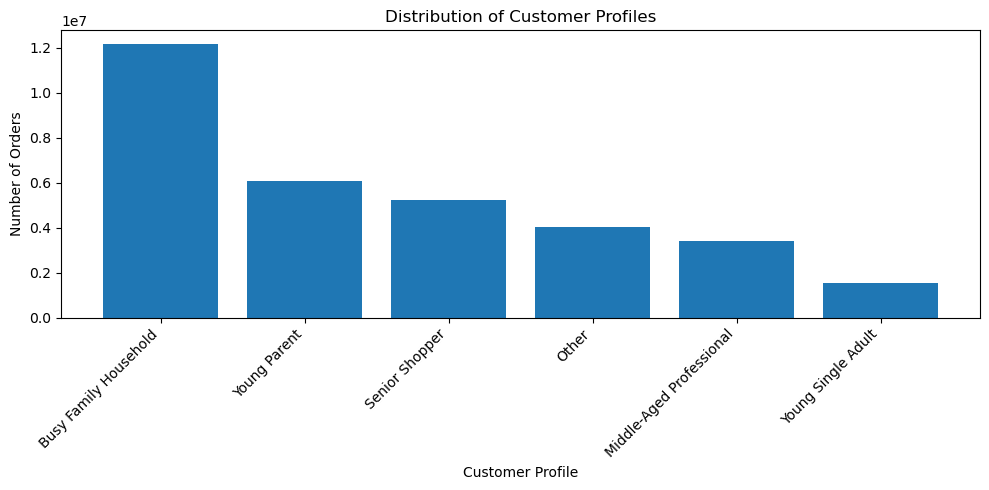

In [38]:
import matplotlib.pyplot as plt

profile_counts = df['profile_flag'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(profile_counts.index, profile_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Customer Profiles")
plt.xlabel("Customer Profile")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# max, mean, and min variables on a customer-profile level for usage frequency and expenditure

# 01 Group by profile and calculate mean, max, min

In [39]:
agg_profiles = df.groupby('profile_flag').agg({
    'order_number': ['mean', 'min', 'max'],
    'prices': ['mean', 'min', 'max']})

agg_profiles

order_number             prices              
                                 mean min max       mean  min      max
profile_flag                                                          
Busy Family Household       17.107195   1  99  11.801645  1.0  99999.0
Middle-Aged Professional    17.276522   1  99  13.426100  1.0  99999.0
Other                       17.304388   1  99  11.318944  1.0  99999.0
Senior Shopper              17.053212   1  99  11.562373  1.0  99999.0
Young Parent                17.144267   1  99  12.178938  1.0  99999.0
Young Single Adult          16.988819   1  99  12.604023  1.0  99999.0

# Comment
All customer profiles show a similar average number of orders (around 17), meaning usage frequency doesn’t vary much by segment. Average product spending is also fairly consistent, with only small differences between profiles. Middle-Aged Professionals spend slightly more per item, while other groups fall close to the overall average. This suggests that profiles differ more in what they buy than in how often they shop or how much they spend per product.

# Comparing Profiles, Regions, and Departments

In [40]:
# Profiles by Region
profiles_by_region = df.groupby(['region', 'profile_flag']).size().unstack(fill_value=0)
profiles_by_region

profile_flag,Busy Family Household,Middle-Aged Professional,Other,Senior Shopper,Young Parent,Young Single Adult
region,,,,,,
Midwest,2835046,845114,946662,1226818,1404114,345641
Northeast,2159540,576014,696823,958466,1060702,276506
South,4063394,1099836,1338971,1738534,2044267,516007
West,3118335,883945,1042973,1328344,1549928,376480


In [41]:
# Profiles by department
profiles_by_dept = df.groupby(['department_id', 'profile_flag']).size().unstack(fill_value=0)
profiles_by_dept

profile_flag,Busy Family Household,Middle-Aged Professional,Other,Senior Shopper,Young Parent,Young Single Adult
department_id,,,,,,
1,845619,237342,272486,363542,415635,101808
2,13501,3836,4556,5969,6729,1700
3,440906,126769,143812,191737,218601,54962
4,3554457,1012794,1157530,1534777,1776360,443373
5,57364,17086,18913,24638,28837,6858
6,99994,29648,32227,43569,50880,12935
7,1012105,270469,345960,438548,495146,125931
8,36946,10431,12318,16178,17154,4697
9,327038,94135,102919,139521,162001,41013


# Comment
Customer profiles show clear behavioral differences across both regions and departments.
Busy Family Households and Young Parents are more prominent in regions with higher average spending and buy mostly fresh produce, dairy, and beverages.
Senior Shoppers appear more uniformly across regions and tend to purchase frozen foods and snacks more frequently.
Young Single Adults show similar behavior across regions but concentrate heavily on convenience categories such as snacks and beverages.
Overall, regions with higher spending tend to have more high-engagement profiles, which suggests that both location and life-stage influence shopping behavior.

# Charts to illustrate your results

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis'
viz_path = os.path.join(base_path, '04 Analysis', 'Visualizations')

os.makedirs(viz_path, exist_ok=True)

# 01 Customer profiles by region 

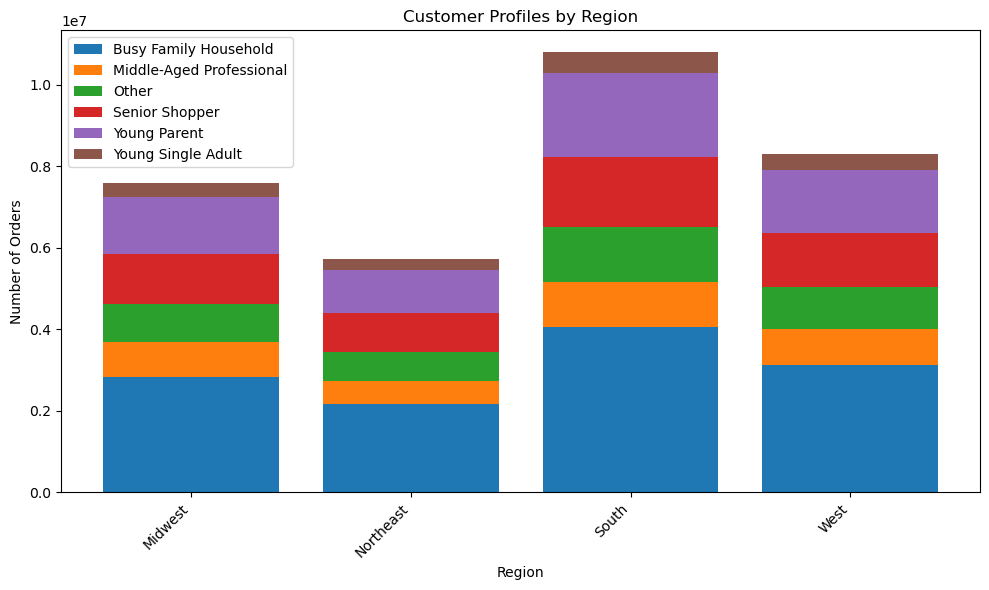

In [43]:
# Aggregate
profiles_by_region = df.groupby(['region', 'profile_flag']).size().unstack(fill_value=0)

# Plot stacked bar
plt.figure(figsize=(10, 6))

bottom = np.zeros(len(profiles_by_region))
for profile in profiles_by_region.columns:
    plt.bar(profiles_by_region.index,
            profiles_by_region[profile].values,
            bottom=bottom,
            label=profile)
    bottom += profiles_by_region[profile].values

plt.xticks(rotation=45, ha='right')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.title('Customer Profiles by Region')
plt.legend()
plt.tight_layout()

In [44]:
plt.savefig(os.path.join(viz_path, 'profiles_by_region.png'),
            dpi=300, bbox_inches='tight')
plt.close()

# 02 Top 5 departments per profile

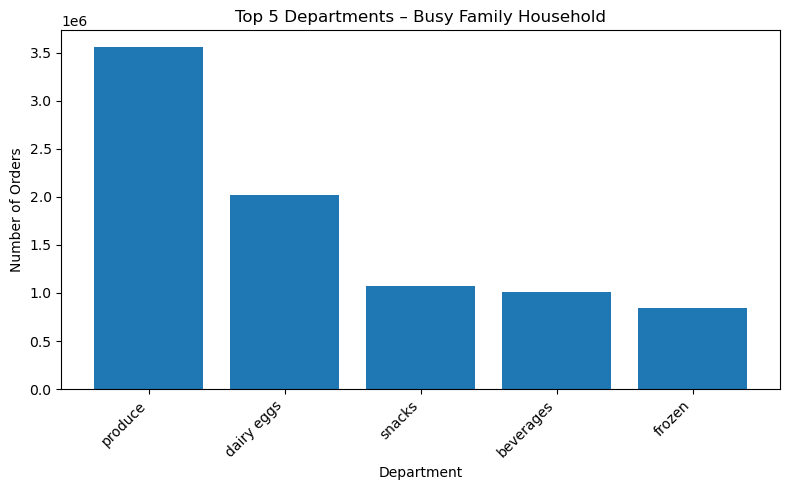

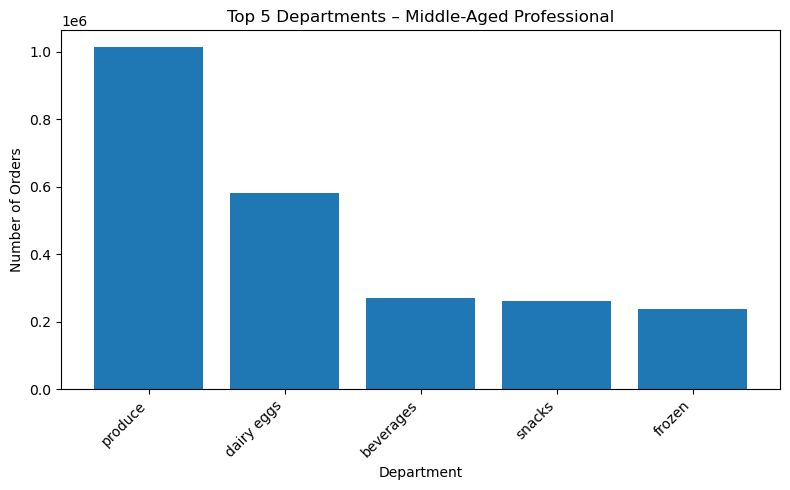

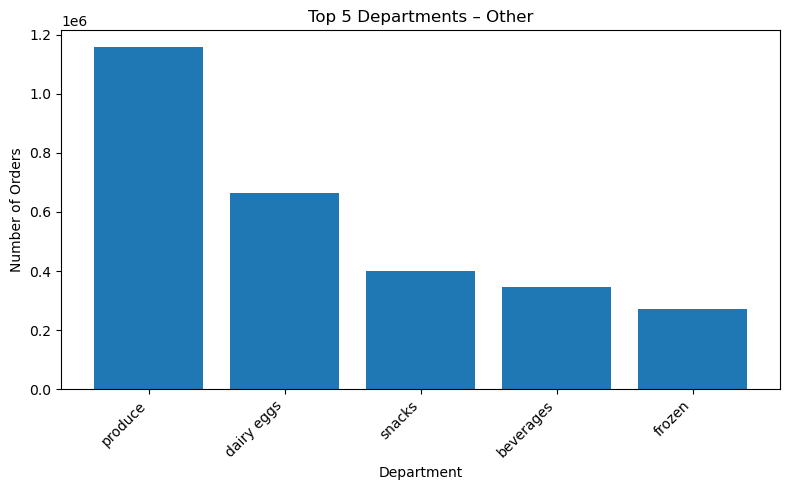

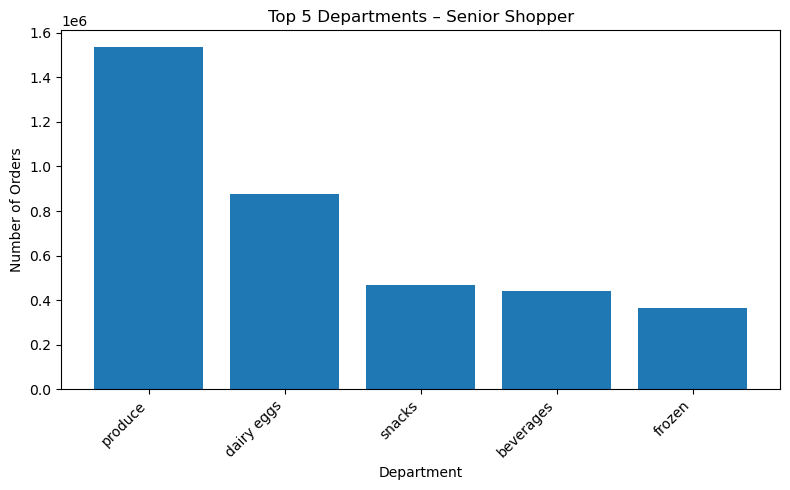

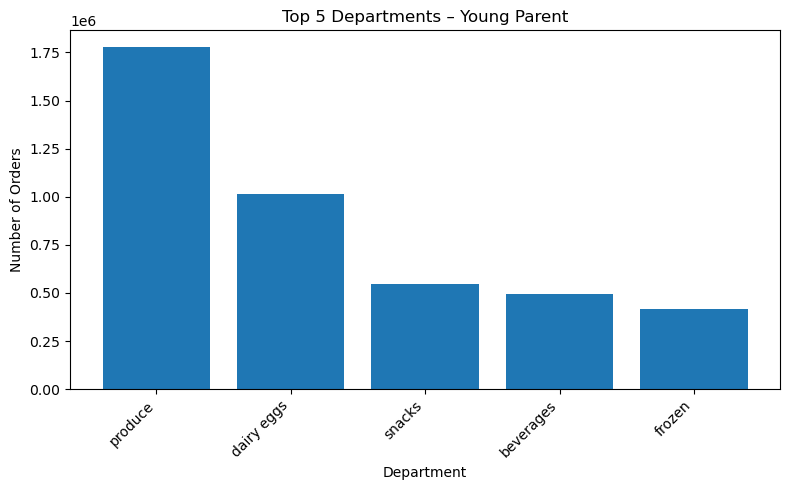

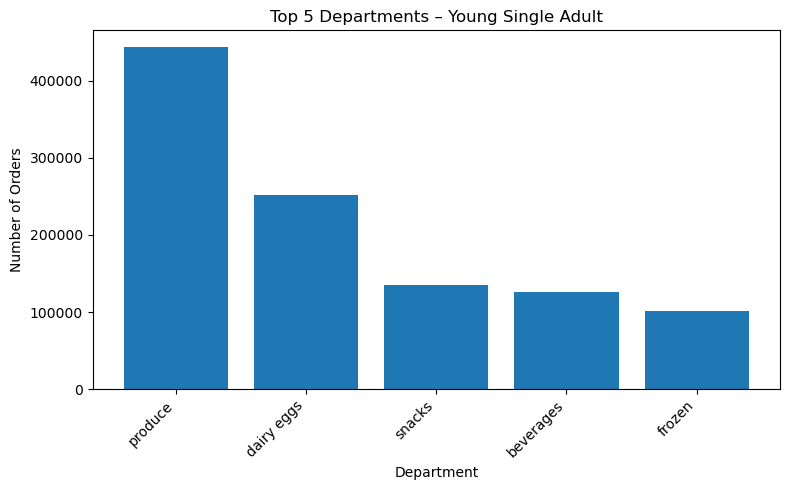

In [47]:
for profile in dept_by_profile['profile_flag'].unique():

# Filter top 5 departments for this profile
sub = (dept_by_profile[dept_by_profile['profile_flag'] == profile].sort_values('counts', ascending=False).head(5))

# Plot
plt.figure(figsize=(8, 5))
plt.bar(sub['department'], sub['counts'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Department')
plt.ylabel('Number of Orders')
plt.title(f'Top 5 Departments – {profile}')
plt.tight_layout()

In [49]:
# File name
filename = f'top5_departments_{profile.replace(" ", "_")}.png'

# SAVE 
plt.savefig(os.path.join(viz_path, filename),dpi=300,bbox_inches='tight')

plt.close()

In [50]:
import os

base_path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis'
final_path = os.path.join(base_path, '02 Data', 'Prepared Data')
os.makedirs(final_path, exist_ok=True)

In [ ]:
df.to_pickle(os.path.join(final_path, 'ords_prods_customers_final.pkl'))